In [1]:
import polars as pl
import pandas as pd
from pathlib import Path

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
)

import matplotlib.pyplot as plt

In [2]:
input_path = Path("../data/processed/flights_model.parquet").resolve()

print("Caminho:", input_path)
print("Existe?", input_path.exists())

df = pl.read_parquet(input_path)

cols_drop = [
    "AIRLINE_DELAY",
    "WEATHER_DELAY",
    "LATE_AIRCRAFT_DELAY",
    "AIR_SYSTEM_DELAY",
    "SECURITY_DELAY",
    "ARRIVAL_DELAY",
]

df_model = df.drop(cols_drop)

feature_cols = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_TIME",
    "DISTANCE",
    "periodo_dia",
]

target_col = "is_delayed"

df_model = df_model.select(feature_cols + [target_col])

print(df.shape)
df.head()

Caminho: /home/doglas/Documents/FIAP/Tech_challange3/fiap-tech-challange-3/flight-delay-ml/data/processed/flights_model.parquet
Existe? True
(5714008, 34)


YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,is_delayed,scheduled_departure_hour,periodo_dia
i64,i64,i64,i64,str,i64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,i64,i64,i64,i8,i64,str
2015,1,1,4,"""AS""",98,"""N407AS""","""ANC""","""SEA""",5,2354,-11,21,15,205,194,169,1448,404,4,430,408,-22,0,0,null,null,null,null,null,null,0,0,"""madrugada"""
2015,1,1,4,"""AA""",2336,"""N3KUAA""","""LAX""","""PBI""",10,2,-8,12,14,280,279,263,2330,737,4,750,741,-9,0,0,null,null,null,null,null,null,0,0,"""madrugada"""
2015,1,1,4,"""US""",840,"""N171US""","""SFO""","""CLT""",20,18,-2,16,34,286,293,266,2296,800,11,806,811,5,0,0,null,null,null,null,null,null,1,0,"""madrugada"""
2015,1,1,4,"""AA""",258,"""N3HYAA""","""LAX""","""MIA""",20,15,-5,15,30,285,281,258,2342,748,8,805,756,-9,0,0,null,null,null,null,null,null,0,0,"""madrugada"""
2015,1,1,4,"""AS""",135,"""N527AS""","""SEA""","""ANC""",25,24,-1,11,35,235,215,199,1448,254,5,320,259,-21,0,0,null,null,null,null,null,null,0,0,"""madrugada"""


In [3]:
df.columns

['YEAR',
 'MONTH',
 'DAY',
 'DAY_OF_WEEK',
 'AIRLINE',
 'FLIGHT_NUMBER',
 'TAIL_NUMBER',
 'ORIGIN_AIRPORT',
 'DESTINATION_AIRPORT',
 'SCHEDULED_DEPARTURE',
 'DEPARTURE_TIME',
 'DEPARTURE_DELAY',
 'TAXI_OUT',
 'WHEELS_OFF',
 'SCHEDULED_TIME',
 'ELAPSED_TIME',
 'AIR_TIME',
 'DISTANCE',
 'WHEELS_ON',
 'TAXI_IN',
 'SCHEDULED_ARRIVAL',
 'ARRIVAL_TIME',
 'ARRIVAL_DELAY',
 'DIVERTED',
 'CANCELLED',
 'CANCELLATION_REASON',
 'AIR_SYSTEM_DELAY',
 'SECURITY_DELAY',
 'AIRLINE_DELAY',
 'LATE_AIRCRAFT_DELAY',
 'WEATHER_DELAY',
 'is_delayed',
 'scheduled_departure_hour',
 'periodo_dia']

In [4]:
df.filter(
    pl.col("ARRIVAL_DELAY").is_null()
).select(
    ["CANCELLED", "DIVERTED"]
).group_by(
    ["CANCELLED", "DIVERTED"]
).len()

CANCELLED,DIVERTED,len
i64,i64,u32


In [5]:
df.with_columns(
    pl.col("ARRIVAL_DELAY").is_null().alias("delay_is_null")
).group_by(
    ["delay_is_null", "CANCELLED", "DIVERTED"]
).len().sort("delay_is_null")

delay_is_null,CANCELLED,DIVERTED,len
bool,i64,i64,u32
false,0,0,5714008


In [6]:
df.filter(
    pl.col("ARRIVAL_DELAY").is_null()
)

YEAR,MONTH,DAY,DAY_OF_WEEK,AIRLINE,FLIGHT_NUMBER,TAIL_NUMBER,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,DEPARTURE_TIME,DEPARTURE_DELAY,TAXI_OUT,WHEELS_OFF,SCHEDULED_TIME,ELAPSED_TIME,AIR_TIME,DISTANCE,WHEELS_ON,TAXI_IN,SCHEDULED_ARRIVAL,ARRIVAL_TIME,ARRIVAL_DELAY,DIVERTED,CANCELLED,CANCELLATION_REASON,AIR_SYSTEM_DELAY,SECURITY_DELAY,AIRLINE_DELAY,LATE_AIRCRAFT_DELAY,WEATHER_DELAY,is_delayed,scheduled_departure_hour,periodo_dia
i64,i64,i64,i64,str,i64,str,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,str,i64,i64,i64,i64,i64,i8,i64,str


In [7]:
df.select([
    pl.col("ARRIVAL_DELAY").null_count().alias("nulls"),
    pl.col("ARRIVAL_DELAY").is_nan().sum().alias("nans"),
])

nulls,nans
u32,u32
0,0


In [8]:
df.select([
    pl.len().alias("total"),
    pl.col("CANCELLED").sum().alias("cancelled"),
    pl.col("DIVERTED").sum().alias("diverted"),
])

total,cancelled,diverted
u32,i64,i64
5714008,0,0


In [9]:
feature_cols = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_TIME",
    "DISTANCE",
    "periodo_dia",
]

target_col = "is_delayed"

df_model = df.select(feature_cols + [target_col])

print(df_model.shape)
df_model.head()

(5714008, 11)


MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,periodo_dia,is_delayed
i64,i64,i64,str,str,str,i64,i64,i64,str,i8
1,1,4,"""AS""","""ANC""","""SEA""",5,205,1448,"""madrugada""",0
1,1,4,"""AA""","""LAX""","""PBI""",10,280,2330,"""madrugada""",0
1,1,4,"""US""","""SFO""","""CLT""",20,286,2296,"""madrugada""",1
1,1,4,"""AA""","""LAX""","""MIA""",20,285,2342,"""madrugada""",0
1,1,4,"""AS""","""SEA""","""ANC""",25,235,1448,"""madrugada""",0


In [10]:
df_pd = df_model.to_pandas()

print(df_pd.shape)
df_pd.head()

(5714008, 11)


,MONTH,DAY,DAY_OF_WEEK,AIRLINE,ORIGIN_AIRPORT,DESTINATION_AIRPORT,SCHEDULED_DEPARTURE,SCHEDULED_TIME,DISTANCE,periodo_dia,is_delayed
0,1,1,4,AS,ANC,SEA,5,205,1448,madrugada,0
1,1,1,4,AA,LAX,PBI,10,280,2330,madrugada,0
2,1,1,4,US,SFO,CLT,20,286,2296,madrugada,1
3,1,1,4,AA,LAX,MIA,20,285,2342,madrugada,0
4,1,1,4,AS,SEA,ANC,25,235,1448,madrugada,0


In [11]:
X = df_pd[feature_cols]
y = df_pd[target_col]

print(X.shape, y.shape)

(5714008, 10) (5714008,)


In [12]:
categorical_features = [
    "AIRLINE",
    "ORIGIN_AIRPORT",
    "DESTINATION_AIRPORT",
    "periodo_dia",
]

numeric_features = [
    "MONTH",
    "DAY",
    "DAY_OF_WEEK",
    "SCHEDULED_DEPARTURE",
    "SCHEDULED_TIME",
    "DISTANCE",
]

print("Categóricas:", categorical_features)
print("Numéricas:", numeric_features)

Categóricas: ['AIRLINE', 'ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'periodo_dia']
Numéricas: ['MONTH', 'DAY', 'DAY_OF_WEEK', 'SCHEDULED_DEPARTURE', 'SCHEDULED_TIME', 'DISTANCE']


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (4571206, 10)
X_test: (1142802, 10)
y_train: (4571206,)
y_test: (1142802,)


In [14]:
numeric_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_transformer = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [15]:
print("""
Modelagem supervisionada:

Nesta etapa, foi utilizado um modelo de classificação para prever se um voo irá atrasar ou não.

O modelo escolhido foi a Regressão Logística, implementada dentro de um pipeline
que inclui etapas de pré-processamento (imputação, encoding e normalização).
""")

log_reg_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(max_iter=1000, random_state=42, class_weight="balanced")),
    ]
)

log_reg_pipeline.fit(X_train, y_train)


Modelagem supervisionada:

Nesta etapa, foi utilizado um modelo de classificação para prever se um voo irá atrasar ou não.

O modelo escolhido foi a Regressão Logística, implementada dentro de um pipeline
que inclui etapas de pré-processamento (imputação, encoding e normalização).



,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers co

In [16]:
rf_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestClassifier(
                n_estimators=150,
                max_depth=12,
                min_samples_split=10,
                min_samples_leaf=5,
                random_state=42,
                n_jobs=-1,
                class_weight="balanced"
            ),
        ),
    ]
)

rf_pipeline.fit(X_train, y_train)
y_pred_rf = rf_pipeline.predict(X_test)
y_prob_rf = rf_pipeline.predict_proba(X_test)[:, 1]

In [17]:
metrics_rf = {
    "accuracy": accuracy_score(y_test, y_pred_rf),
    "precision": precision_score(y_test, y_pred_rf),
    "recall": recall_score(y_test, y_pred_rf),
    "f1": f1_score(y_test, y_pred_rf),
    "roc_auc": roc_auc_score(y_test, y_prob_rf),
}

metrics_rf

{'accuracy': 0.5635840679312777,
 'precision': 0.4321229292646136,
 'recall': 0.6204744369026712,
 'f1': 0.5094468974105006,
 'roc_auc': 0.6180973516042438}

In [19]:
y_pred_lr = log_reg_pipeline.predict(X_test)
y_prob_lr = log_reg_pipeline.predict_proba(X_test)[:, 1]

metrics_lr = {
    "accuracy": accuracy_score(y_test, y_pred_lr),
    "precision": precision_score(y_test, y_pred_lr),
    "recall": recall_score(y_test, y_pred_lr),
    "f1": f1_score(y_test, y_pred_lr),
    "roc_auc": roc_auc_score(y_test, y_prob_lr),
}

comparison_df = pd.DataFrame(
    [
        {"modelo": "Logistic Regression", **metrics_lr},
        {"modelo": "Random Forest", **metrics_rf},
    ]
)

comparison_df

,modelo,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression,0.585578,0.449599,0.600814,0.514322,0.620340
1,Random Forest,0.563584,0.432123,0.620474,0.509447,0.618097


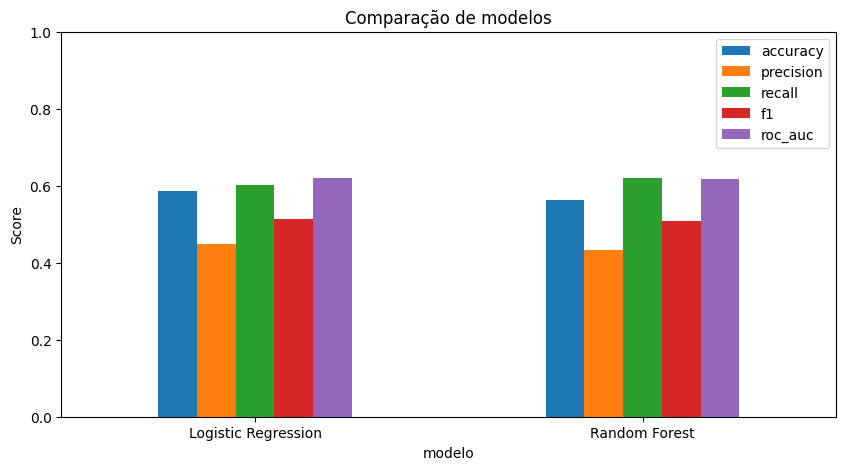

In [20]:
plot_df = comparison_df.set_index("modelo")

plot_df.plot(kind="bar", figsize=(10, 5))
plt.title("Comparação de modelos")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.ylim(0, 1)
plt.show()

In [21]:
print("""
Comparação de modelos:

- Regressão Logística: modelo linear, mais simples e interpretável
- Random Forest: modelo baseado em árvores, capaz de capturar relações não lineares

O Random Forest tende a apresentar melhor desempenho em dados complexos,
enquanto a regressão logística oferece maior interpretabilidade.

A escolha do melhor modelo será baseada nas métricas de avaliação.
""")


Comparação de modelos:

- Regressão Logística: modelo linear, mais simples e interpretável
- Random Forest: modelo baseado em árvores, capaz de capturar relações não lineares

O Random Forest tende a apresentar melhor desempenho em dados complexos,
enquanto a regressão logística oferece maior interpretabilidade.

A escolha do melhor modelo será baseada nas métricas de avaliação.

